<a href="https://colab.research.google.com/github/jhagihara/Hockey-Predictions/blob/main/hockey_analysis_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading Data

In [ ]:
import pandas as pd
url = 'https://nuhuskies.com/sports/womens-ice-hockey/stats/2023-24/connecticut/boxscore/12666'
nu_wih = pd.read_html(url)
len(nu_wih)

14

In [ ]:
# Now to build a big loop for all the games
opponents = ['penn-state', 'penn-state', 'liu', 'liu',
             'boston-university', 'boston-university', 'merrimack',
             'st-cloud-state', 'sacred-heart', 'holy-cross', 'holy-cross',
             'connecticut', 'connecticut', 'providence', 'providence',
             'vermont', 'boston-college', 'providence', 'boston-university',
             'yale', 'holy-cross', 'maine', 'maine', 'harvard', 'new-hampshire',
             'boston-university', 'merrimack', 'merrimack', 'new-hampshire',
             'new-hampshire', 'connecticut', 'maine', 'boston-college',
             'boston-college', 'vermont', 'vermont', 'merrimack', 'new-hampshire',
             'connecticut', 'penn-state', 'penn-state', 'quinnipiac', 'quinnipiac',
             'boston-university', 'boston-university', 'holy-cross', 'holy-cross']

game_numbers = [12650, 12653, 12654, 12655, 12656, 12657, 12658,
                12660, 12662, 12663, 12664, 12665, 12666, 12668,
                12671, 12673, 12675, 12677, 12678, 12679, 12680,
                12681, 12682, 12683, 12684, 12685, 12686, 12687,
                12688, 12689, 12690, 12691, 12692, 12693, 12694,
                12695, 13051, 13103, 13104, 13184, 13185, 13186,
                13187, 13188, 13189, 13190, 13191]


In [ ]:
# Nested dictionary
from datetime import timedelta
from collections import defaultdict
full_dict = defaultdict(dict)

# The Loop
for idx in range(len(game_numbers)):
    year = "2024-25" if game_numbers[idx] > 13104 else "2023-24"
    url = f'https://nuhuskies.com/sports/womens-ice-hockey/stats/{year}/{opponents[idx]}/boxscore/{game_numbers[idx]}'
    nu_wih = pd.read_html(url)

    # Initialize a dictionary with lists as default values (though lists are not needed here)
    test_dict = defaultdict(list)

    # Clean up the team names by removing "Winner " from the "Team" column in nu_wih[0]
    nu_wih[0].iloc[:, 0] = nu_wih[0].iloc[:, 0].str.replace("Winner  ", "")

    # Assign home and visit teams to the dictionary
    test_dict['home_team'] = nu_wih[0].loc[1, "Team"]
    test_dict['visit_team'] = nu_wih[0].loc[0, "Team"]

    # Extract linescores for home and visit teams
    home_linescore = nu_wih[0].iloc[1, 1:-1]
    visit_linescore = nu_wih[0].iloc[0, 1:-1]

    # Assign home linescore values to the dictionary
    for col in home_linescore.index:
        col2 = "home_" + col  # Create a key like "home_1st", "home_2nd", etc.
        test_dict[col2] = home_linescore[col]  # Direct assignment

    # Assign visit linescore values to the dictionary
    for col in visit_linescore.index:
        col2 = "visit_" + col  # Create a key like "visit_1st", "visit_2nd", etc.
        test_dict[col2] = visit_linescore[col]  # Direct assignment

    # Function to convert the time string (e.g., "02:30") into a timedelta object
    def convert_to_timedelta(time_str):
        minutes, seconds = map(int, time_str.split(':'))
        return timedelta(minutes=minutes, seconds=seconds)

    # Function to format timedelta as "MM:SS"
    def format_timedelta(td):
        total_seconds = int(td.total_seconds())
        minutes, seconds = divmod(total_seconds, 60)
        return f"{minutes:02}:{seconds:02}"

    # Process home team's power play stats by period from nu_wih[3]
    df_home = nu_wih[3].iloc[:-1, :]  # Exclude last row

    if 'Prd' in df_home.columns:
        for period in df_home['Prd'].unique():
            i = int(period[0])  # Extract the period number (e.g., 1st -> 1)

            # Filter the data for the specific period
            period_df = df_home[df_home['Prd'] == period]

            # Sum shots, opp-shots, and calculate total elapsed power play time
            shots_sum = period_df['Shots'].sum()
            opp_shots_sum = period_df['Opp-Shots'].sum()
            total_elapsed = sum(period_df['Elapsed'].apply(convert_to_timedelta), timedelta())
            total_elapsed_str = format_timedelta(total_elapsed)

            # Store the calculated values in the dictionary
            test_dict[f'home_pp_elapsed_{i}'] = total_elapsed_str
            test_dict[f'home_pp_shots_{i}'] = shots_sum
            test_dict[f'home_pp_oppshots_{i}'] = opp_shots_sum
    else:
        test_dict[f'home_pp_elapsed_{i}'] = '00:00'
        test_dict[f'home_pp_shots_{i}'] = 0
        test_dict[f'home_pp_oppshots_{i}'] = 0

    # Process visit team's power play stats by period from nu_wih[2]
    df_visit = nu_wih[2].iloc[:-1, :]  # Exclude last row

    if 'Prd' in df_visit.columns:
        for period in df_visit['Prd'].unique():
            i = int(period[0])  # Extract the period number

            # Filter the data for the specific period
            period_df = df_visit[df_visit['Prd'] == period]

            # Sum shots, opp-shots, and calculate total elapsed power play time
            shots_sum = period_df['Shots'].sum()
            opp_shots_sum = period_df['Opp-Shots'].sum()
            total_elapsed = sum(period_df['Elapsed'].apply(convert_to_timedelta), timedelta())
            total_elapsed_str = format_timedelta(total_elapsed)

            # Store the calculated values in the dictionary
            test_dict[f'visit_pp_elapsed_{i}'] = total_elapsed_str
            test_dict[f'visit_pp_shots_{i}'] = shots_sum
            test_dict[f'visit_pp_oppshots_{i}'] = opp_shots_sum
    else:
        test_dict[f'visit_pp_elapsed_{i}'] = '00:00'
        test_dict[f'visit_pp_shots_{i}'] = 0
        test_dict[f'visit_pp_oppshots_{i}'] = 0
    # Process home team performance data from nu_wih[6]
    df_home_perf = nu_wih[6].iloc[-1, :]  # Last row

    # Keep relevant columns ('A', 'Shots By Period', 'BLK')
    columns_to_keep = df_home_perf.loc[df_home_perf.index.get_level_values(0).isin(['A', 'Shots By Period', 'BLK'])]

    # Store home team performance data in the dictionary
    for col in columns_to_keep.index:
        if col[0] == 'Shots By Period':
            test_dict[f"home_shots_p{col[1]}"] = columns_to_keep[col]
        else:
            test_dict[f'home_{col[0]}'] = columns_to_keep[col]

    # Process visit team performance data from nu_wih[5]
    df_visit_perf = nu_wih[5].iloc[-1, :]  # Last row

    # Keep relevant columns ('A', 'Shots By Period', 'BLK')
    columns_to_keep = df_visit_perf.loc[df_visit_perf.index.get_level_values(0).isin(['A', 'Shots By Period', 'BLK'])]

    # Store visit team performance data in the dictionary
    for col in columns_to_keep.index:
        if col[0] == 'Shots By Period':
            test_dict[f"visit_shots_p{col[1]}"] = columns_to_keep[col]
        else:
            test_dict[f'visit_{col[0]}'] = columns_to_keep[col]

    # Store faceoff wins for home and visit teams
    test_dict['home_faceoff_w'] = nu_wih[9].iloc[-1, -1]  # Last row, last column
    test_dict['visit_faceoff_w'] = nu_wih[9].iloc[-1, -2]  # Last row, second-to-last column

    print(f'Index {idx} worked, moving to {idx+1}')
    full_dict[f'game_{idx}'] = test_dict

Index 0 worked, moving to 1
Index 1 worked, moving to 2
Index 2 worked, moving to 3
Index 3 worked, moving to 4
Index 4 worked, moving to 5
Index 5 worked, moving to 6
Index 6 worked, moving to 7
Index 7 worked, moving to 8
Index 8 worked, moving to 9
Index 9 worked, moving to 10
Index 10 worked, moving to 11
Index 11 worked, moving to 12
Index 12 worked, moving to 13
Index 13 worked, moving to 14
Index 14 worked, moving to 15
Index 15 worked, moving to 16
Index 16 worked, moving to 17
Index 17 worked, moving to 18
Index 18 worked, moving to 19
Index 19 worked, moving to 20
Index 20 worked, moving to 21
Index 21 worked, moving to 22
Index 22 worked, moving to 23
Index 23 worked, moving to 24
Index 24 worked, moving to 25
Index 25 worked, moving to 26
Index 26 worked, moving to 27
Index 27 worked, moving to 28
Index 28 worked, moving to 29
Index 29 worked, moving to 30
Index 30 worked, moving to 31
Index 31 worked, moving to 32
Index 32 worked, moving to 33
Index 33 worked, moving to 34

#Initial Observations and Feature Engineering

In [ ]:
# Convert the nested dictionary into a DataFrame
df_2023_24 = pd.DataFrame.from_dict(full_dict, orient='index')

# Adding the latest game of the 2425 season
df_2023_24.loc[len(df_2023_24)] = ['Northeastern', 'Quinnipiac',
                                   2, 0, 2, 1, 0, 1,
                                   02.14, 3, 0, 00.00, 0, 0, 00.00, 0, 0,
                                   00.22, 1, 0, 02.00, 5, 0, 03.50, 7, 0,
                                   6, 8, 7, 9, 14, 4, 10, 11, 14, 10, 30, 28,
                                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
df_2023_24.loc[len(df_2023_24)] = ['Northeastern', 'Quinnipiac',
                                   0, 0, 0, 0, 2, 1,
                                   04.00, 2, 0, 01.47, 1, 0, 00.00, 0, 0,
                                   00.00, 0, 0, 01.47, 0, 0, 00.38, 1, 0,
                                   0, 8, 9, 11, 17, 5, 8, 11, 7, 9, 25, 36,
                                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

df_2023_24.loc[len(df_2023_24)] = ['Northeastern', 'Boston University',
                                   1, 2, 1, 0, 0, 0,
                                   02.00, 1, 0, 02.00, 2, 0, 02.00, 2, 0,
                                   00.20, 2, 0, 02.00, 0, 0, 02.00, 7, 0,
                                   7, 10, 8, 8, 9, 0, 8, 7, 11, 11, 26, 32,
                                   0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# Display the DataFrame
df_2023_24.head()

# Checking if the last row in the dataframe was added correctly
last_row = df_2023_24.tail(1)
print(last_row)

       home_team         visit_team  home_1  home_2  home_3  visit_1  visit_2  \
49  Northeastern  Boston University       1       2       1        0        0   

    visit_3 home_pp_elapsed_1  home_pp_shots_1  ...  visit_OT 1  \
49        0               2.0              1.0  ...         0.0   

   visit_pp_elapsed_4  visit_pp_shots_4  visit_pp_oppshots_4 home_shots_p4  \
49                  0               0.0                  0.0           0.0   

    visit_shots_p4  home_OT 2 visit_OT 2  home_shots_p5  visit_shots_p5  
49             0.0        0.0        0.0            0.0             0.0  

[1 rows x 49 columns]


In [ ]:
df_2023_24.columns

Index(['home_team', 'visit_team', 'home_1', 'home_2', 'home_3', 'visit_1',
       'visit_2', 'visit_3', 'home_pp_elapsed_1', 'home_pp_shots_1',
       'home_pp_oppshots_1', 'home_pp_elapsed_2', 'home_pp_shots_2',
       'home_pp_oppshots_2', 'home_pp_elapsed_3', 'home_pp_shots_3',
       'home_pp_oppshots_3', 'visit_pp_elapsed_1', 'visit_pp_shots_1',
       'visit_pp_oppshots_1', 'visit_pp_elapsed_2', 'visit_pp_shots_2',
       'visit_pp_oppshots_2', 'visit_pp_elapsed_3', 'visit_pp_shots_3',
       'visit_pp_oppshots_3', 'home_A', 'home_shots_p1', 'home_shots_p2',
       'home_shots_p3', 'home_BLK', 'visit_A', 'visit_shots_p1',
       'visit_shots_p2', 'visit_shots_p3', 'visit_BLK', 'home_faceoff_w',
       'visit_faceoff_w', 'home_OT 1', 'visit_OT 1', 'visit_pp_elapsed_4',
       'visit_pp_shots_4', 'visit_pp_oppshots_4', 'home_shots_p4',
       'visit_shots_p4', 'home_OT 2', 'visit_OT 2', 'home_shots_p5',
       'visit_shots_p5', 'home_W'],
      dtype='object')

In [ ]:
import numpy as np

# make a list of all entries for home_team and visit_team
home_teams = df_2023_24['home_team'].unique()
visit_teams = df_2023_24['visit_team'].unique()
all_teams = np.concatenate((home_teams, visit_teams))

In [ ]:
# Need to first get the final score:
home_score = df_2023_24.home_1 + df_2023_24.home_2 + df_2023_24.home_3 + df_2023_24['home_OT 1'].fillna(0) + df_2023_24['home_OT 2'].fillna(0)
visit_score = df_2023_24.visit_1 + df_2023_24.visit_2 + df_2023_24.visit_3 + df_2023_24['visit_OT 1'].fillna(0) + df_2023_24['visit_OT 2'].fillna(0)
home_team_W = (home_score > visit_score).astype(int)
home_team_W

,0
game_0,1
game_1,0
game_2,0
game_3,0
game_4,0
game_5,1
game_6,1
game_7,0
game_8,0
game_9,0


In [ ]:
# Check some intuitive features and compare their values in wins vs losses
import numpy as np
Choose_stat = 'home_pp_shots_1' # for example, home_pp_shots_1

Win_rows = home_team_W == 1
Loss_rows = home_team_W == 0
Stat_mean_wins = df_2023_24.loc[Win_rows,Choose_stat].mean()
Stat_mean_losses = df_2023_24.loc[Loss_rows,Choose_stat].mean()
Stat_diff_standard_error = np.sqrt((df_2023_24.loc[Win_rows,Choose_stat].var()/sum(Win_rows)) + (df_2023_24.loc[Loss_rows,Choose_stat].var()/sum(Loss_rows)))
if np.abs((Stat_mean_wins - Stat_mean_losses)/Stat_diff_standard_error) > 3:
    Big_diff = 'a BIG'
else:
    Big_diff = 'not that big a'

print(f'The mean value for {Choose_stat} in wins: {Stat_mean_wins} \nThe mean value for {Choose_stat} in losses: {Stat_mean_losses} \nThis is {Big_diff} difference')

The mean value for home_pp_shots_1 in wins: 1.8666666666666667 
The mean value for home_pp_shots_1 in losses: 3.0 
This is not that big a difference


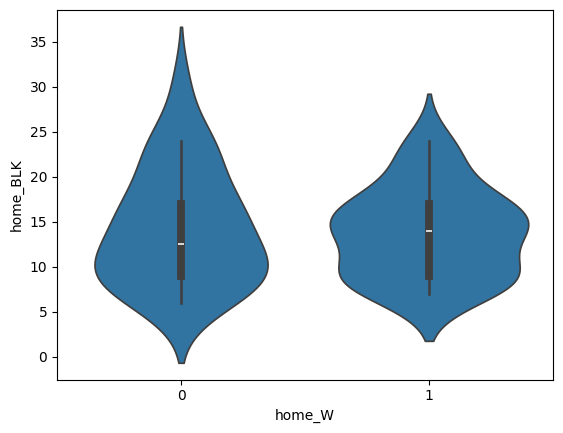

In [ ]:
# Can also make some plots
import seaborn as sns

# add the win column to the data
df_new = df_2023_24
df_new['home_W'] = home_team_W
sns.violinplot(data=df_new, x="home_W", y="home_BLK");

In [ ]:
df_new.isna().sum()

,0
home_team,0
visit_team,0
home_1,0
home_2,0
home_3,0
visit_1,0
visit_2,0
visit_3,0
home_pp_elapsed_1,18
home_pp_shots_1,18


In [ ]:
#impute all missing values with 0
df_new = df_new.fillna(0)
df_new.isna().sum()

,0
home_team,0
visit_team,0
home_1,0
home_2,0
home_3,0
visit_1,0
visit_2,0
visit_3,0
home_pp_elapsed_1,0
home_pp_shots_1,0


In [ ]:
df_new.duplicated().sum()

0

In [ ]:
df_new.columns

Index(['home_team', 'visit_team', 'home_1', 'home_2', 'home_3', 'visit_1',
       'visit_2', 'visit_3', 'home_pp_elapsed_1', 'home_pp_shots_1',
       'home_pp_oppshots_1', 'home_pp_elapsed_2', 'home_pp_shots_2',
       'home_pp_oppshots_2', 'home_pp_elapsed_3', 'home_pp_shots_3',
       'home_pp_oppshots_3', 'visit_pp_elapsed_1', 'visit_pp_shots_1',
       'visit_pp_oppshots_1', 'visit_pp_elapsed_2', 'visit_pp_shots_2',
       'visit_pp_oppshots_2', 'visit_pp_elapsed_3', 'visit_pp_shots_3',
       'visit_pp_oppshots_3', 'home_A', 'home_shots_p1', 'home_shots_p2',
       'home_shots_p3', 'home_BLK', 'visit_A', 'visit_shots_p1',
       'visit_shots_p2', 'visit_shots_p3', 'visit_BLK', 'home_faceoff_w',
       'visit_faceoff_w', 'home_OT 1', 'visit_OT 1', 'visit_pp_elapsed_4',
       'visit_pp_shots_4', 'visit_pp_oppshots_4', 'home_shots_p4',
       'visit_shots_p4', 'home_OT 2', 'visit_OT 2', 'home_shots_p5',
       'visit_shots_p5', 'home_W'],
      dtype='object')

In [ ]:
# make new column "saves"
df_new['home_saves_1'] = df_new['home_shots_p1'] - df_new['home_1']
df_new['home_saves_2'] = df_new['home_shots_p2'] - df_new['home_2']
df_new['home_saves_3'] = df_new['home_shots_p3'] - df_new['home_3']
df_new['visit_saves_1'] = df_new['visit_shots_p1'] - df_new['visit_1']
df_new['visit_saves_2'] = df_new['visit_shots_p2'] - df_new['visit_2']
df_new['visit_saves_3'] = df_new['visit_shots_p3'] - df_new['visit_3']

In [ ]:
import pandas as pd  # import pandas

# Convert all pp_elapsed columns to total seconds
for column in df_new.columns:
    if 'pp_elapsed' in column:
        # Convert to timedelta first
        df_new[column] = pd.to_timedelta(df_new[column], errors='coerce')
        # Then extract total seconds
        df_new[column] = df_new[column].dt.total_seconds()

In [ ]:
# calculates the point differential for home and away
for i in range(3):
  df_new['home_plus_minus'] = df_new['home_' + str(i+1)] - df_new['visit_' + str(i+1)]
  df_new['visit_plus_minus'] = df_new['visit_' + str(i+1)] - df_new['home_' + str(i+1)]
# List of all home columns
new_cols_home = df_new.columns[df_new.columns.str.startswith('home')].tolist()
# List of all visit columns
new_cols_visit = df_new.columns[df_new.columns.str.startswith('visit')].tolist()
# list of all
pred_cols = new_cols_visit + new_cols_home

In [ ]:
# impute missing values again
df_new = df_new.fillna(0)

#Data Preparation

In [ ]:
# getting dummy variables for df_new
df_dummies = pd.get_dummies(df_new, columns=['home_team', 'visit_team'])

In [ ]:
#train test split
from sklearn.model_selection import train_test_split
X = df_dummies.drop(columns=['home_W'])
y = df_dummies['home_W']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
# checking the size of x_train and x_test
print(X_train.shape)
print(X_test.shape)

(40, 85)
(10, 85)


In [ ]:
# min max scaling x train and x test
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [ ]:
# getting input layer number
input_layer = X_train_normalized.shape[1]
input_layer

85

#Feed-Forward Neural Network


In [ ]:
import tensorflow as tf
# Fixing the seed for random number generators
np.random.seed(42)

import random
random.seed(42)

tf.random.set_seed(42)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_1 = Sequential()

# First hidden layer with 128 neurons and relu activation function
model_1.add(Dense(128, activation='relu', input_shape=(input_layer,)))

# switching 20% of neurons off randomly at each iteration to avoid overfitting
model_1.add(Dropout(0.2))

# Second hidden layer with 64 neurons and relu activation function
model_1.add(Dense(64, activation='relu'))

# switching 10% of neurons off randomly at each iteration to avoid overfitting
model_1.add(Dropout(0.1))

# Output layer with only one neuron and sigmoid as activation function
model_1.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# using binary crossentropy loss and adamax optimizer for accuracy
model_1.compile(loss = 'crossentropy', optimizer='SGD', metrics=['accuracy'])
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          11,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,329 (75.50 KB)

 Trainable params: 19,329 (75.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training with 150 epochs and splitting 10%
history_1 = model_1.fit(X_train_normalized,
                    y_train,
                    validation_split=0.2,
                    epochs=150,
                    verbose=2)

Epoch 1/150
1/1 - 1s - 1s/step - accuracy: 0.3750 - loss: 0.7278 - val_accuracy: 0.6250 - val_loss: 0.6879
Epoch 2/150
1/1 - 0s - 57ms/step - accuracy: 0.3438 - loss: 0.7272 - val_accuracy: 0.6250 - val_loss: 0.6874
Epoch 3/150
1/1 - 0s - 46ms/step - accuracy: 0.4375 - loss: 0.7235 - val_accuracy: 0.6250 - val_loss: 0.6869
Epoch 4/150
1/1 - 0s - 47ms/step - accuracy: 0.4062 - loss: 0.7009 - val_accuracy: 0.6250 - val_loss: 0.6865
Epoch 5/150
1/1 - 0s - 65ms/step - accuracy: 0.3750 - loss: 0.7296 - val_accuracy: 0.6250 - val_loss: 0.6860
Epoch 6/150
1/1 - 0s - 129ms/step - accuracy: 0.4062 - loss: 0.7226 - val_accuracy: 0.6250 - val_loss: 0.6857
Epoch 7/150
1/1 - 0s - 47ms/step - accuracy: 0.5625 - loss: 0.7022 - val_accuracy: 0.6250 - val_loss: 0.6852
Epoch 8/150
1/1 - 0s - 51ms/step - accuracy: 0.3125 - loss: 0.7326 - val_accuracy: 0.6250 - val_loss: 0.6847
Epoch 9/150
1/1 - 0s - 46ms/step - accuracy: 0.4375 - loss: 0.7105 - val_accuracy: 0.6250 - val_loss: 0.6842
Epoch 10/150
1/1 - 0

In [ ]:
# Clearing the backend
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
# Fixing the seed for random number generators
np.random.seed(42)

import random
random.seed(42)

tf.random.set_seed(42)

In [ ]:
!pip install scikeras
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from scikeras.wrappers import KerasClassifier, KerasRegressor

In [ ]:
def create_model(optimizer='adam', activation='relu', neurons=32, dropout_rate = .2):
    model_1 = Sequential()

    # First hidden layer
    model_1.add(Dense(neurons, activation=activation, input_shape=(input_layer,)))

    # switching neurons off randomly at each iteration to avoid overfitting
    model_1.add(Dropout(dropout_rate))

    # Second hidden layer with half neurons and activation function
    model_1.add(Dense(neurons // 2, activation=activation))

    # switching neurons off randomly at each iteration to avoid overfitting
    model_1.add(Dropout(dropout_rate // 2))

    # Output layer with only one neuron
    model_1.add(Dense(1, activation='sigmoid'))

    # using binary crossentropy loss and adamax optimizer for accuracy
    model_1.compile(loss = 'binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model_1

In [ ]:
# Custom KerasClassifier wrapper
class CustomKerasClassifier(KerasClassifier):
    def __init__(self, neurons=32, activation='relu', dropout_rate=0.2, *args, **kwargs):
        self.neurons = neurons
        self.activation = activation
        self.dropout_rate = dropout_rate
        super().__init__(*args, **kwargs)

    def _keras_build_fn(self, **kwargs):
        return create_model(neurons=self.neurons, activation=self.activation, dropout_rate=self.dropout_rate)

In [ ]:
# Create the KerasClassifier without activation in the constructor
"""
model = CustomKerasClassifier()

# Define the grid search parameters
param_grid = {
    'batch_size': [16, 32],
    'epochs': [50, 100],
    'optimizer': ['adam', 'sgd'],
    'activation': ['relu', 'tanh'],
    'neurons': [16, 32, 64],
    'dropout_rate': [0.1, 0.2],
    'validation_split': [0.1, 0.2]
}

# Create the scoring method
scoring = make_scorer(accuracy_score)

# Create the GridSearchCV object
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, n_jobs=-1, cv=3)

# Fit the grid search
grid_result = grid.fit(X_train_normalized, y_train)

# Print the best parameters and score
print("Best parameters: ", grid_result.best_params_)
print("Best score: ", grid_result.best_score_)
"""


'\nmodel = CustomKerasClassifier()\n\n# Define the grid search parameters\nparam_grid = {\n    \'batch_size\': [16, 32],\n    \'epochs\': [50, 100],\n    \'optimizer\': [\'adam\', \'sgd\'],\n    \'activation\': [\'relu\', \'tanh\'],\n    \'neurons\': [16, 32, 64],\n    \'dropout_rate\': [0.1, 0.2],\n    \'validation_split\': [0.1, 0.2]\n}\n\n# Create the scoring method\nscoring = make_scorer(accuracy_score)\n\n# Create the GridSearchCV object\ngrid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, n_jobs=-1, cv=3)\n\n# Fit the grid search\ngrid_result = grid.fit(X_train_normalized, y_train)\n\n# Print the best parameters and score\nprint("Best parameters: ", grid_result.best_params_)\nprint("Best score: ", grid_result.best_score_)\n'

In [ ]:
# tuned ffnn
model_2 = Sequential()

# First hidden layer with 128 neurons and relu activation function
model_2.add(Dense(128, activation='tanh', input_shape=(input_layer,)))

# switching 20% of neurons off randomly at each iteration to avoid overfitting
model_2.add(Dropout(0.2))

# Second hidden layer with 64 neurons and relu activation function
model_2.add(Dense(64, activation='tanh'))

# switching 10% of neurons off randomly at each iteration to avoid overfitting
model_2.add(Dropout(0.1))

# Output layer with only one neuron and sigmoid as activation function
model_2.add(Dense(1, activation='sigmoid'))

In [ ]:
# using binary crossentropy loss and SGD optimizer for accuracy
model_2.compile(loss = 'binary_crossentropy', optimizer='sgd', metrics=['accuracy'])
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          11,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,329 (75.50 KB)

 Trainable params: 19,329 (75.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training with 150 epochs and splitting 10%
history_2 = model_2.fit(X_train_normalized,
                    y_train,
                    validation_split=0.1,
                    epochs=150,
                    verbose=2, batch_size=32)

Epoch 1/150
2/2 - 2s - 757ms/step - accuracy: 0.3611 - loss: 0.7620 - val_accuracy: 0.5000 - val_loss: 0.7333
Epoch 2/150
2/2 - 0s - 29ms/step - accuracy: 0.4722 - loss: 0.7438 - val_accuracy: 0.5000 - val_loss: 0.7310
Epoch 3/150
2/2 - 0s - 32ms/step - accuracy: 0.5000 - loss: 0.7516 - val_accuracy: 0.5000 - val_loss: 0.7319
Epoch 4/150
2/2 - 0s - 67ms/step - accuracy: 0.3889 - loss: 0.7664 - val_accuracy: 0.5000 - val_loss: 0.7336
Epoch 5/150
2/2 - 0s - 63ms/step - accuracy: 0.4167 - loss: 0.7373 - val_accuracy: 0.5000 - val_loss: 0.7343
Epoch 6/150
2/2 - 0s - 70ms/step - accuracy: 0.4444 - loss: 0.7625 - val_accuracy: 0.5000 - val_loss: 0.7365
Epoch 7/150
2/2 - 0s - 174ms/step - accuracy: 0.5556 - loss: 0.7226 - val_accuracy: 0.5000 - val_loss: 0.7350
Epoch 8/150
2/2 - 0s - 107ms/step - accuracy: 0.4167 - loss: 0.7377 - val_accuracy: 0.5000 - val_loss: 0.7320
Epoch 9/150
2/2 - 0s - 133ms/step - accuracy: 0.5000 - loss: 0.7159 - val_accuracy: 0.7500 - val_loss: 0.7323
Epoch 10/150
2/

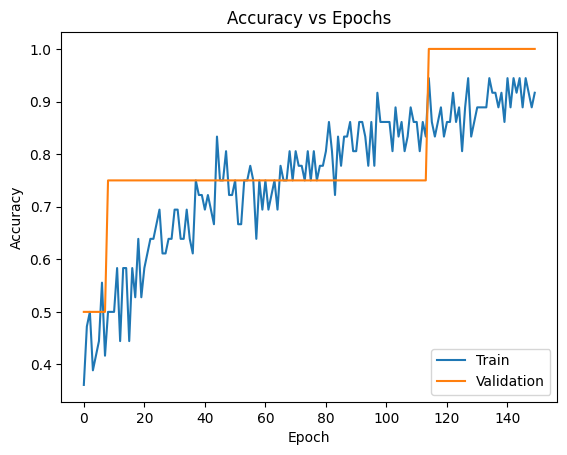

In [ ]:
# accuracy vs epochs
import matplotlib.pyplot as plt
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

In [ ]:
# test results
model_2.evaluate(X_test_normalized, y_test, verbose = 1)
test_pred = np.round(model_2.predict(X_test_normalized))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9000 - loss: 0.3993
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.75      0.86         4

    accuracy                           0.90        10
   macro avg       0.93      0.88      0.89        10
weighted avg       0.91      0.90      0.90        10



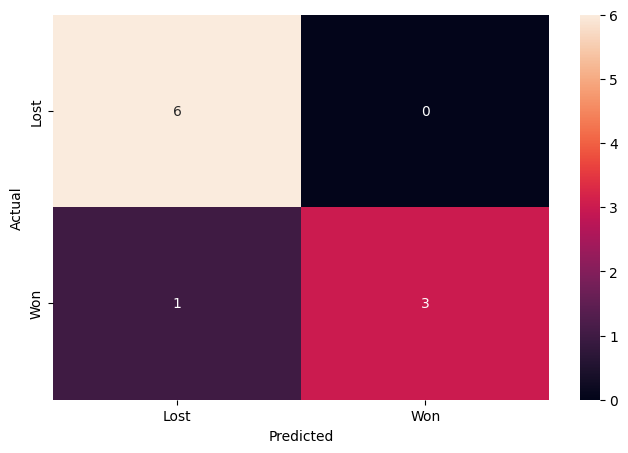

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(classification_report(y_test, test_pred))
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True,  fmt='.0f',xticklabels=['Lost', 'Won'], yticklabels=['Lost', 'Won'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#Predictor

In [ ]:
def predict_game(away_name, home_name):
    try:
        # Use the model
        model = model_2

        # Check if the teams are in the data
        home_team_col = f'home_team_{home_name}'
        away_team_col = f'visit_team_{away_name}'

        home_not_found = home_team_col not in df_dummies.columns
        away_not_found = away_team_col not in df_dummies.columns

        # Setting up the new dataframes and handling if the data was not found
        if not home_not_found:
            df_home = df_dummies[df_dummies[home_team_col] == 1]
        else:
            df_home = pd.DataFrame()

        if not away_not_found:
            df_away = df_dummies[df_dummies[away_team_col] == 1]
        else:
            df_away = pd.DataFrame()

        # Get the input shape of the model to define feature names
        n_features = model.input_shape[1]
        feature_names = model.feature_names_in_ if hasattr(model, 'feature_names_in_') else df_dummies.columns[:n_features]

        # Check that we have the right number of features
        if len(feature_names) != n_features:
            raise ValueError(f"Expected {n_features} features based on model input shape, but found {len(feature_names)}.")

        # Splitting feature names into home and away features
        home_features = [f for f in feature_names if f.startswith('home_')]
        away_features = [f for f in feature_names if f.startswith('visit_')]

        # Calculate averages for all features
        numeric_cols = df_dummies.select_dtypes(include='number').columns
        averages = df_dummies[numeric_cols].mean().to_dict()

        # Home stats
        if home_not_found:
            home_stats = [averages.get(col, 0) for col in home_features]
        else:
            home_stats = [df_home[col].iloc[-1] if col in df_home.columns else averages.get(col, 0) for col in home_features]

        # Away stats
        if away_not_found:
            away_stats = [averages.get(col, 0) for col in away_features]
        else:
            away_stats = [df_away[col].iloc[-1] if col in df_away.columns else averages.get(col, 0) for col in away_features]

        # Combine the stats into a single list for prediction
        new_stats = away_stats + home_stats

        # Check the length of new_stats to ensure it's correct
        if len(new_stats) != n_features:
            raise ValueError(f"Input features do not match model input shape: expected {n_features}, got {len(new_stats)}")

        # Reshape for model input (add batch dimension)
        new_stats_reshaped = np.array(new_stats).reshape(1, -1)

        # Predict using the Keras model
        home_win_prob = model.predict(new_stats_reshaped)[0][0]

        # Calculate away win probability
        away_win_prob = 1 - home_win_prob

        # Determine the winner and return the prediction with win probabilities
        if home_win_prob > away_win_prob:
            win_prob = str(round(home_win_prob * 100, 1)) + '%'
            return f'The home team ({home_name}) has a {win_prob} chance of winning'
        else:
            win_prob = str(round(away_win_prob * 100, 1)) + '%'
            return f'The away team ({away_name}) has a {win_prob} chance of winning'

    except Exception as e:
        return f"Unable to predict the game due to an error: {str(e)}"


In [ ]:
predict_game("Northeastern", "Providence")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


'The away team (Northeastern) has a 80.4% chance of winning'